Notebook-4: Real-World Traffic Dataset Integration
Adaptive Non-Uniform Cellular Automata (A-NUCA)

Primary Dataset: NGSIM (US-101 & I-80)

Secondary Dataset: highD (later)

Estimated Cells: 180–220

Modules: 10

"""
==============================================================
Notebook-4

Real World Traffic Dataset Integration

Adaptive Non-Uniform Cellular Automata (A-NUCA)

Primary Dataset
---------------
NGSIM (US101 + I80)

Secondary Dataset
-----------------
highD


In [ ]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12,5)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/A_NUCA_Project/"

NGSIM_PATH = PROJECT_PATH + "NGSIM/"

HIGHD_PATH = PROJECT_PATH + "highD/"

OUTPUT_PATH = PROJECT_PATH + "Notebook4_Output/"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [ ]:
folders = [

    PROJECT_PATH,

    NGSIM_PATH,

    OUTPUT_PATH

]

for folder in folders:

    print(folder)

    print("Exists :", os.path.exists(folder))

    print("-"*50)

/content/drive/MyDrive/A_NUCA_Project/
Exists : True
--------------------------------------------------
/content/drive/MyDrive/A_NUCA_Project/NGSIM/
Exists : True
--------------------------------------------------
/content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/
Exists : True
--------------------------------------------------


In [ ]:
trajectory_files = []

for root, dirs, files in os.walk(NGSIM_PATH):

    for file in files:

        if file.lower().endswith((".csv", ".txt")):

            trajectory_files.append(

                os.path.join(root,file)

            )

trajectory_files

['/content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0820am-0835am.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0805am-0820am.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0750am-0805am.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/I80/trajectories-0400-0415.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/I80/trajectories-0500-0515.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/I80/trajectories-0515-0530.csv']

In [ ]:
print("="*70)

print("Trajectory Files Found")

print("="*70)

for i,file in enumerate(trajectory_files):

    print(i+1,file)

Trajectory Files Found
1 /content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0820am-0835am.csv
2 /content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0805am-0820am.csv
3 /content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0750am-0805am.csv
4 /content/drive/MyDrive/A_NUCA_Project/NGSIM/I80/trajectories-0400-0415.csv
5 /content/drive/MyDrive/A_NUCA_Project/NGSIM/I80/trajectories-0500-0515.csv
6 /content/drive/MyDrive/A_NUCA_Project/NGSIM/I80/trajectories-0515-0530.csv


In [ ]:
US101_FILES = []

I80_FILES = []

for file in trajectory_files:

    name = file.lower()

    if "101" in name:

        US101_FILES.append(file)

    elif "80" in name:

        I80_FILES.append(file)

print("US101 :",len(US101_FILES))

print("I80 :",len(I80_FILES))

US101 : 3
I80 : 3


In [ ]:
dataset_information = {

"NGSIM":{

"Sampling Frequency":10,

"Speed Unit":"ft/sec",

"Distance Unit":"feet",

"Acceleration":"ft/sec²"

},

"highD":{

"Sampling Frequency":25,

"Speed Unit":"m/sec",

"Distance Unit":"meter",

"Acceleration":"m/sec²"

}

}

dataset_information

{'NGSIM': {'Sampling Frequency': 10,
  'Speed Unit': 'ft/sec',
  'Distance Unit': 'feet',
  'Acceleration': 'ft/sec²'},
 'highD': {'Sampling Frequency': 25,
  'Speed Unit': 'm/sec',
  'Distance Unit': 'meter',
  'Acceleration': 'm/sec²'}}

In [ ]:
DATASET = "US101"

print("Current Dataset :",DATASET)

Current Dataset : US101


In [ ]:
if DATASET=="US101":

    selected_files = US101_FILES

elif DATASET=="I80":

    selected_files = I80_FILES

selected_files

['/content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0820am-0835am.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0805am-0820am.csv',
 '/content/drive/MyDrive/A_NUCA_Project/NGSIM/US101/trajectories-0750am-0805am.csv']

In [ ]:
trajectory_df = pd.read_csv(

    selected_files[0]

)

In [ ]:
trajectory_df.shape

(1048575, 18)

In [ ]:
trajectory_df.columns.tolist()

['Vehicle_ID',
 'Frame_ID',
 'Total_Frames',
 'Global_Time',
 'Local_X',
 'Local_Y',
 'Global_X',
 'Global_Y',
 'v_Length',
 'v_Width',
 'v_Class',
 'v_Vel',
 'v_Acc',
 'Lane_ID',
 'Preceeding',
 'Following',
 'Space_Hdwy',
 'Time_Hdwy']

In [ ]:
trajectory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Vehicle_ID    1048575 non-null  int64  
 1   Frame_ID      1048575 non-null  int64  
 2   Total_Frames  1048575 non-null  int64  
 3   Global_Time   1048575 non-null  int64  
 4   Local_X       1048575 non-null  float64
 5   Local_Y       1048575 non-null  float64
 6   Global_X      1048575 non-null  float64
 7   Global_Y      1048575 non-null  float64
 8   v_Length      1048575 non-null  float64
 9   v_Width       1048575 non-null  float64
 10  v_Class       1048575 non-null  int64  
 11  v_Vel         1048575 non-null  float64
 12  v_Acc         1048575 non-null  float64
 13  Lane_ID       1048575 non-null  int64  
 14  Preceeding    1048575 non-null  int64  
 15  Following     1048575 non-null  int64  
 16  Space_Hdwy    1048575 non-null  float64
 17  Time_Hdwy     1048575 non-n

In [ ]:
trajectory_df.isnull().sum()

,0
Vehicle_ID,0
Frame_ID,0
Total_Frames,0
Global_Time,0
Local_X,0
Local_Y,0
Global_X,0
Global_Y,0
v_Length,0
v_Width,0


In [ ]:
trajectory_df.duplicated().sum()

np.int64(0)

In [ ]:
trajectory_df.describe()

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceeding,Following,Space_Hdwy,Time_Hdwy
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,6.893392e+02,3.630524e+03,8.525107e+02,1.118849e+12,2.992187e+01,1.079270e+03,6.451870e+06,1.872649e+06,1.607410e+01,6.709961e+00,2.017605e+00,2.514985e+01,7.944355e-02,3.011797e+00,6.629442e+02,6.742659e+02,6.054572e+01,1.985282e+02
std,3.944759e+02,1.854135e+03,1.774676e+02,1.854135e+05,1.666223e+01,6.042268e+02,4.525471e+02,4.017779e+02,4.037528e+00,6.743631e-01,1.469039e-01,1.234745e+01,4.313940e+00,1.465057e+00,4.162053e+02,4.162665e+02,3.560799e+01,1.383732e+03
min,1.000000e+00,5.000000e+00,1.600000e+02,1.118849e+12,3.690000e-01,0.000000e+00,6.451065e+06,1.871883e+06,6.500000e+00,3.500000e+00,1.000000e+00,0.000000e+00,-1.120000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.360000e+02,1.941000e+03,7.350000e+02,1.118849e+12,1.763900e+01,5.579420e+02,6.451476e+06,1.872303e+06,1.450000e+01,6.400000e+00,2.000000e+00,1.517000e+01,-3.400000e-01,2.000000e+00,2.930000e+02,3.040000e+02,3.995000e+01,1.820000e+00
50%,7.010000e+02,3.664000e+03,8.580000e+02,1.118849e+12,2.987200e+01,1.052515e+03,6.451847e+06,1.872663e+06,1.550000e+01,6.900000e+00,2.000000e+00,2.502000e+01,0.000000e+00,3.000000e+00,6.670000e+02,6.810000e+02,5.409000e+01,2.490000e+00
75%,1.051000e+03,5.306000e+03,9.580000e+02,1.118849e+12,4.182900e+01,1.600805e+03,6.452261e+06,1.872991e+06,1.650000e+01,6.900000e+00,2.000000e+00,3.450000e+01,5.500000e-01,4.000000e+00,1.039000e+03,1.051000e+03,7.373000e+01,3.480000e+00
max,1.317000e+03,7.184000e+03,1.328000e+03,1.118849e+12,7.553300e+01,2.235252e+03,6.452740e+06,1.873398e+06,6.550000e+01,8.500000e+00,3.000000e+00,9.530000e+01,1.120000e+01,8.000000e+00,2.004000e+03,2.004000e+03,6.776400e+02,9.999990e+03


In [ ]:
memory = trajectory_df.memory_usage(

deep=True

).sum()/1024**2

print(memory,"MB")

143.9999885559082 MB


In [ ]:
trajectory_df.head()

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceeding,Following,Space_Hdwy,Time_Hdwy
0,1,137,421,1118848770700,52.660,73.916,6451113.236,1873317.970,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0
1,1,138,421,1118848770800,52.648,76.416,6451114.916,1873316.119,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0
2,1,139,421,1118848770900,52.635,78.915,6451116.596,1873314.268,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0
3,1,140,421,1118848771000,52.622,81.416,6451118.277,1873312.417,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0
4,1,141,421,1118848771100,52.609,83.916,6451119.957,1873310.566,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0


In [ ]:
trajectory_df.tail()

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceeding,Following,Space_Hdwy,Time_Hdwy
1048570,1317,6107,1114,1118849367700,38.320,162.991,6451184.340,1873261.226,16.0,5.4,2,12.67,-0.03,4,1311,1324,48.87,3.86
1048571,1317,6108,1114,1118849367800,38.353,164.261,6451185.179,1873260.276,16.0,5.4,2,12.64,-0.57,4,1311,1324,48.53,3.84
1048572,1317,6109,1114,1118849367900,38.393,165.524,6451186.020,1873259.313,16.0,5.4,2,12.57,-0.91,4,1311,1324,48.19,3.83
1048573,1317,6110,1114,1118849368000,38.418,166.779,6451186.847,1873258.387,16.0,5.4,2,12.47,-1.22,4,1311,1324,47.86,3.84
1048574,1317,6111,1114,1118849368100,38.405,168.024,6451187.700,1873257.490,16.0,5.4,2,12.29,-1.93,4,1311,1324,47.54,3.87


In [ ]:
trajectory_df.Vehicle_ID.nunique()

1298

In [ ]:
trajectory_df.Frame_ID.nunique()

7180

In [ ]:
summary = {

"Rows":len(trajectory_df),

"Columns":len(trajectory_df.columns),

"Vehicles":trajectory_df.Vehicle_ID.nunique(),

"Frames":trajectory_df.Frame_ID.nunique()

}

summary

{'Rows': 1048575, 'Columns': 18, 'Vehicles': 1298, 'Frames': 7180}

In [ ]:
display(

trajectory_df.sample(10)

)

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceeding,Following,Space_Hdwy,Time_Hdwy
303385,385,1785,938,1118848935500,6.012,269.437,6451281.387,1873205.793,16.5,6.9,2,19.70,1.60,1,380,391,81.63,4.14
599967,810,4104,688,1118849167400,39.953,784.404,6451639.328,1872832.680,16.5,6.9,2,25.03,-0.20,4,806,816,59.08,2.36
526483,704,3439,729,1118849100900,18.541,412.361,6451376.252,1873097.561,20.0,8.5,2,32.50,-0.05,2,700,707,51.70,1.59
11549,19,158,819,1118848772800,39.193,117.843,6451152.626,1873294.278,15.0,6.9,2,25.86,-5.70,4,15,0,51.17,1.98
854730,1128,6047,1006,1118849361700,32.063,1962.323,6452532.220,1872063.524,23.0,8.4,3,34.51,0.00,3,1107,1138,51.11,1.48
649039,883,4779,779,1118849234900,19.488,2002.419,6452570.933,1872047.179,15.5,7.4,2,24.99,0.00,2,877,886,35.77,1.43
598731,808,4196,700,1118849176600,29.036,1100.456,6451884.494,1872632.732,15.0,7.4,2,39.08,6.81,3,801,811,105.57,2.70
141504,188,1127,323,1118848869700,62.539,736.236,6451588.228,1872847.487,15.5,6.4,2,47.51,0.00,6,185,191,65.31,1.37
1016692,1286,6472,988,1118849404200,29.726,936.534,6451760.288,1872739.936,17.0,7.4,2,34.31,1.46,3,1281,1290,64.34,1.88
524971,702,3393,776,1118849096300,6.830,310.148,6451310.140,1873176.866,15.5,6.9,2,32.30,7.05,1,695,705,99.51,3.08


In [ ]:
trajectory_df.to_csv(

OUTPUT_PATH+"raw_dataset.csv",

index=False

)

In [ ]:
pd.DataFrame(summary,index=[0]).to_csv(

OUTPUT_PATH+"dataset_summary.csv",

index=False

)

In [ ]:
print("="*70)

print("Dataset Loaded Successfully")

print("="*70)

print("Rows :",len(trajectory_df))

print("Vehicles :",trajectory_df.Vehicle_ID.nunique())

print("Frames :",trajectory_df.Frame_ID.nunique())

print("="*70)

Dataset Loaded Successfully
Rows : 1048575
Vehicles : 1298
Frames : 7180


In [ ]:
print("="*70)

print("Notebook-4")

print("Module-1 Completed Successfully")

print("="*70)

print("✓ Google Drive")

print("✓ Dataset Detection")

print("✓ Automatic File Discovery")

print("✓ Dataset Validation")

print("✓ Raw Dataset Export")

print("="*70)

Notebook-4
Module-1 Completed Successfully
✓ Google Drive
✓ Dataset Detection
✓ Automatic File Discovery
✓ Dataset Validation
✓ Raw Dataset Export


Notebook-4 Module-2
Data Cleaning & Standardization

(Cells 31–60)

Objectives
Standardize NGSIM data
Remove invalid records
Convert units to SI
Create unified dataset format
Prepare inputs for A-NUCA state generation

In [ ]:
# ============================================================
# Cell 31
# Create Working Copy
# ============================================================

ngsim_df = trajectory_df.copy()

print("Working Dataset Shape :", ngsim_df.shape)

Working Dataset Shape : (1048575, 18)


In [ ]:
# ============================================================
# Cell 32
# Data Types
# ============================================================

display(ngsim_df.dtypes)

,0
Vehicle_ID,int64
Frame_ID,int64
Total_Frames,int64
Global_Time,int64
Local_X,float64
Local_Y,float64
Global_X,float64
Global_Y,float64
v_Length,float64
v_Width,float64


In [ ]:
# ============================================================
# Cell 33
# Rename Columns
# ============================================================

column_mapping = {

    "Vehicle_ID":"VehicleID",
    "Frame_ID":"FrameID",
    "Global_Time":"Time",
    "Local_X":"X",
    "Local_Y":"Y",
    "v_Length":"Length",
    "v_Width":"Width",
    "v_Class":"VehicleClass",
    "v_Vel":"Speed_ftps",
    "v_Acc":"Acceleration_ftps2",
    "Lane_ID":"Lane",
    "Preceeding":"FrontVehicle",
    "Following":"RearVehicle",
    "Space_Hdwy":"SpaceHeadway_ft",
    "Time_Hdwy":"TimeHeadway_sec"

}

ngsim_df.rename(columns=column_mapping,
                 inplace=True)

ngsim_df.columns

Index(['VehicleID', 'FrameID', 'Total_Frames', 'Time', 'X', 'Y', 'Global_X',
       'Global_Y', 'Length', 'Width', 'VehicleClass', 'Speed_ftps',
       'Acceleration_ftps2', 'Lane', 'FrontVehicle', 'RearVehicle',
       'SpaceHeadway_ft', 'TimeHeadway_sec'],
      dtype='object')

In [ ]:
# ============================================================
# Cell 34
# Missing Values
# ============================================================

missing = ngsim_df.isnull().sum()

display(missing[missing>0])

,0


In [ ]:
# ============================================================
# Cell 35
# Remove Duplicate Rows
# ============================================================

before = len(ngsim_df)

ngsim_df.drop_duplicates(inplace=True)

after = len(ngsim_df)

print("Duplicates Removed :", before-after)

Duplicates Removed : 0


In [ ]:
# ============================================================
# Cell 36
# Remove Invalid Vehicles
# ============================================================

ngsim_df = ngsim_df[
    ngsim_df.VehicleID > 0
]

print(ngsim_df.shape)

(1048575, 18)


In [ ]:
# ============================================================
# Cell 37
# Lane Validation
# ============================================================

ngsim_df = ngsim_df[
    ngsim_df.Lane > 0
]

print("Unique Lanes")

print(sorted(
    ngsim_df.Lane.unique()
))

Unique Lanes
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [ ]:
# ============================================================
# Cell 38
# Unit Conversion
# ============================================================

FEET_TO_METER = 0.3048

ngsim_df["X_m"] = ngsim_df["X"] * FEET_TO_METER

ngsim_df["Y_m"] = ngsim_df["Y"] * FEET_TO_METER

ngsim_df["Length_m"] = ngsim_df["Length"] * FEET_TO_METER

ngsim_df["Width_m"] = ngsim_df["Width"] * FEET_TO_METER

ngsim_df["Speed_mps"] = ngsim_df["Speed_ftps"] * FEET_TO_METER

ngsim_df["Acceleration_mps2"] = ngsim_df["Acceleration_ftps2"] * FEET_TO_METER

ngsim_df["SpaceHeadway_m"] = ngsim_df["SpaceHeadway_ft"] * FEET_TO_METER

In [ ]:
# ============================================================
# Cell 39
# Speed in km/h
# ============================================================

ngsim_df["Speed_kmph"] = ngsim_df["Speed_mps"] * 3.6

In [ ]:
# ============================================================
# Cell 40
# Time Conversion
# ============================================================

ngsim_df["Time"] = pd.to_datetime(
    ngsim_df["Time"],
    unit="ms"
)

In [ ]:
# ============================================================
# Cell 41
# Vehicle Classes
# ============================================================

vehicle_map = {

1:"Motorcycle",

2:"Passenger Car",

3:"Truck"

}

ngsim_df["VehicleType"] = ngsim_df["VehicleClass"].map(vehicle_map)

In [ ]:
display(

ngsim_df.head()

)

,VehicleID,FrameID,Total_Frames,Time,X,Y,Global_X,Global_Y,Length,Width,VehicleClass,Speed_ftps,Acceleration_ftps2,Lane,FrontVehicle,RearVehicle,SpaceHeadway_ft,TimeHeadway_sec,X_m,Y_m,Length_m,Width_m,Speed_mps,Acceleration_mps2,SpaceHeadway_m,Speed_kmph,VehicleType
0,1,137,421,2005-06-15 15:19:30.700,52.660,73.916,6451113.236,1873317.970,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.050768,22.529597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
1,1,138,421,2005-06-15 15:19:30.800,52.648,76.416,6451114.916,1873316.119,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.047110,23.291597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
2,1,139,421,2005-06-15 15:19:30.900,52.635,78.915,6451116.596,1873314.268,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.043148,24.053292,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
3,1,140,421,2005-06-15 15:19:31.000,52.622,81.416,6451118.277,1873312.417,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.039186,24.815597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
4,1,141,421,2005-06-15 15:19:31.100,52.609,83.916,6451119.957,1873310.566,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.035223,25.577597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car


In [ ]:
summary = {

"Vehicles":

ngsim_df.VehicleID.nunique(),

"Frames":

ngsim_df.FrameID.nunique(),

"Rows":

len(ngsim_df),

"Lanes":

ngsim_df.Lane.nunique()

}

summary

{'Vehicles': 1298, 'Frames': 7180, 'Rows': 1048575, 'Lanes': 8}

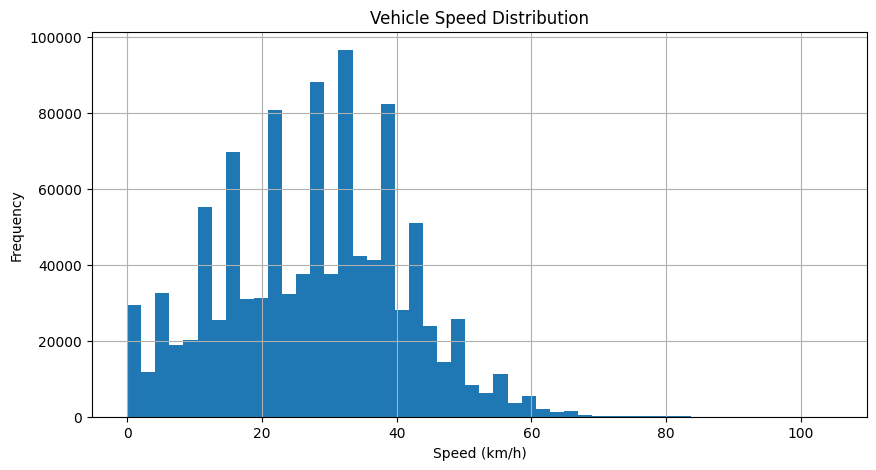

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(

ngsim_df.Speed_kmph,

bins=50

)

plt.xlabel("Speed (km/h)")

plt.ylabel("Frequency")

plt.title("Vehicle Speed Distribution")

plt.grid()

plt.show()

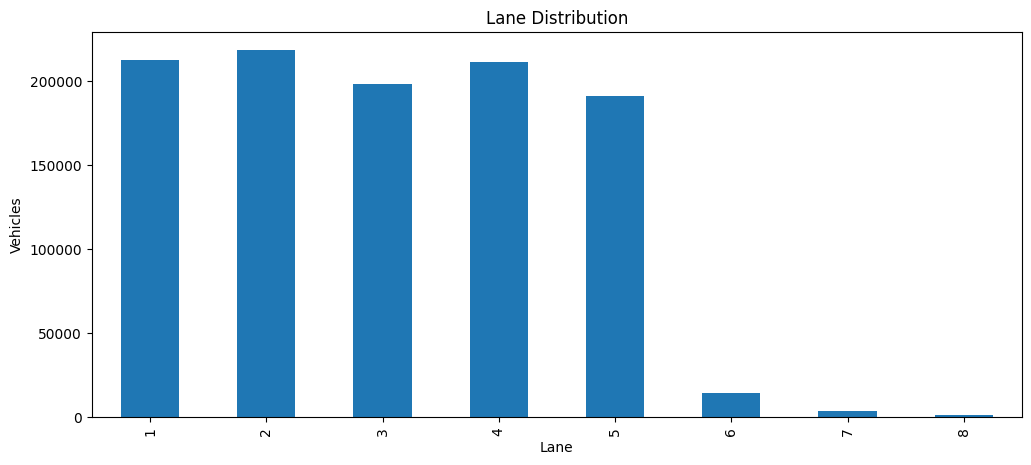

In [ ]:
lane_counts = ngsim_df.Lane.value_counts()

lane_counts.sort_index().plot(

kind="bar"

)

plt.title("Lane Distribution")

plt.xlabel("Lane")

plt.ylabel("Vehicles")

plt.show()

In [ ]:
display(

ngsim_df.VehicleType.value_counts()

)

,count
VehicleType,
Passenger Car,1025621
Truck,20707
Motorcycle,2247


In [ ]:
display(

ngsim_df[

["SpaceHeadway_m",

"TimeHeadway_sec"]

].describe()

)

,SpaceHeadway_m,TimeHeadway_sec
count,1.048575e+06,1.048575e+06
mean,1.845434e+01,1.985282e+02
std,1.085332e+01,1.383732e+03
min,0.000000e+00,0.000000e+00
25%,1.217676e+01,1.820000e+00
50%,1.648663e+01,2.490000e+00
75%,2.247290e+01,3.480000e+00
max,2.065447e+02,9.999990e+03


In [ ]:
quality = pd.DataFrame({

"Metric":[

"Rows",

"Vehicles",

"Frames",

"Lanes",

"Missing Values"

],

"Value":[

len(ngsim_df),

ngsim_df.VehicleID.nunique(),

ngsim_df.FrameID.nunique(),

ngsim_df.Lane.nunique(),

ngsim_df.isnull().sum().sum()

]

})

quality

,Metric,Value
0,Rows,1048575
1,Vehicles,1298
2,Frames,7180
3,Lanes,8
4,Missing Values,0


In [ ]:
clean_path = OUTPUT_PATH + "ngsim_cleaned.csv"

ngsim_df.to_csv(

clean_path,

index=False

)

print(clean_path)

/content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/ngsim_cleaned.csv


In [ ]:
print("="*70)
print("Notebook-4 : Module-2 Completed Successfully")
print("="*70)
print("✓ Data Cleaning")
print("✓ Unit Conversion")
print("✓ Column Standardization")
print("✓ Vehicle Type Mapping")
print("✓ Data Quality Validation")
print("✓ Clean Dataset Exported")
print("="*70)

Notebook-4 : Module-2 Completed Successfully
✓ Data Cleaning
✓ Unit Conversion
✓ Column Standardization
✓ Vehicle Type Mapping
✓ Data Quality Validation
✓ Clean Dataset Exported


Notebook-4
Module-3 : Trajectory Reconstruction & Vehicle Dynamics
(Cells 61–95)
Objectives
Reconstruct each vehicle trajectory
Compute trajectory statistics
Detect lane changes
Compute travel distance and duration
Compute vehicle dynamics
Export reconstructed trajectories

In [ ]:
# ============================================================
# Cell 61
# Create Trajectory Dataset
# ============================================================

trajectory_data = ngsim_df.copy()

print("Trajectory Dataset Shape :", trajectory_data.shape)

Trajectory Dataset Shape : (1048575, 27)


In [ ]:
# ============================================================
# Cell 62
# Sort by Vehicle and Time
# ============================================================

trajectory_data.sort_values(

    ["VehicleID","FrameID"],

    inplace=True

)

trajectory_data.reset_index(

    drop=True,

    inplace=True

)

trajectory_data.head()

,VehicleID,FrameID,Total_Frames,Time,X,Y,Global_X,Global_Y,Length,Width,VehicleClass,Speed_ftps,Acceleration_ftps2,Lane,FrontVehicle,RearVehicle,SpaceHeadway_ft,TimeHeadway_sec,X_m,Y_m,Length_m,Width_m,Speed_mps,Acceleration_mps2,SpaceHeadway_m,Speed_kmph,VehicleType
0,1,137,421,2005-06-15 15:19:30.700,52.660,73.916,6451113.236,1873317.970,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.050768,22.529597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
1,1,138,421,2005-06-15 15:19:30.800,52.648,76.416,6451114.916,1873316.119,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.047110,23.291597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
2,1,139,421,2005-06-15 15:19:30.900,52.635,78.915,6451116.596,1873314.268,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.043148,24.053292,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
3,1,140,421,2005-06-15 15:19:31.000,52.622,81.416,6451118.277,1873312.417,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.039186,24.815597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car
4,1,141,421,2005-06-15 15:19:31.100,52.609,83.916,6451119.957,1873310.566,15.0,6.4,2,25.0,0.0,5,0,0,0.0,0.0,16.035223,25.577597,4.572,1.95072,7.62,0.0,0.0,27.432,Passenger Car


In [ ]:
# ============================================================
# Cell 63
# Number of Vehicles
# ============================================================

total_vehicles = trajectory_data.VehicleID.nunique()

print("Total Trajectories :", total_vehicles)

Total Trajectories : 1298


In [ ]:
# ============================================================
# Cell 64
# Frames per Vehicle
# ============================================================

frames_per_vehicle = (

trajectory_data

.groupby("VehicleID")

.size()

.reset_index(name="Frames")

)

display(frames_per_vehicle.head())

,VehicleID,Frames
0,1,421
1,2,687
2,3,786
3,4,456
4,5,654


Cell 65 — Travel Time

NGSIM sampling frequency = 10 Hz

In [ ]:
# ============================================================
# Cell 65
# Travel Duration
# ============================================================

frames_per_vehicle["Duration_sec"] = (

frames_per_vehicle["Frames"]/10

)

display(frames_per_vehicle.head())

,VehicleID,Frames,Duration_sec
0,1,421,42.1
1,2,687,68.7
2,3,786,78.6
3,4,456,45.6
4,5,654,65.4


In [ ]:
# ============================================================
# Cell 66
# Distance Travelled
# ============================================================

distance = (

trajectory_data

.groupby("VehicleID")

.agg(

Start=("Y_m","min"),

End=("Y_m","max")

)

)

distance["Distance_m"] = (

distance["End"]-

distance["Start"]

)

distance.head()

,Start,End,Distance_m
VehicleID,,,
1,22.529597,446.197634,423.668038
2,22.350374,658.632566,636.282192
3,20.921167,658.935233,638.014066
4,163.996726,666.453734,502.457009
5,23.422356,657.883978,634.461622


In [ ]:
# ============================================================
# Cell 67
# Merge
# ============================================================

trajectory_stats = (

frames_per_vehicle

.merge(

distance,

left_on="VehicleID",

right_index=True

)

)

trajectory_stats.head()

,VehicleID,Frames,Duration_sec,Start,End,Distance_m
0,1,421,42.1,22.529597,446.197634,423.668038
1,2,687,68.7,22.350374,658.632566,636.282192
2,3,786,78.6,20.921167,658.935233,638.014066
3,4,456,45.6,163.996726,666.453734,502.457009
4,5,654,65.4,23.422356,657.883978,634.461622


In [ ]:
# ============================================================
# Cell 68
# Average Speed
# ============================================================

avg_speed = (

trajectory_data

.groupby("VehicleID")

.Speed_kmph

.mean()

)

trajectory_stats["AverageSpeed_kmph"] = (

trajectory_stats.VehicleID

.map(avg_speed)

)

In [ ]:
# ============================================================
# Cell 69
# Maximum Speed
# ============================================================

trajectory_stats["MaxSpeed_kmph"] = (

trajectory_data

.groupby("VehicleID")

.Speed_kmph

.max()

.values

)

In [ ]:
# ============================================================
# Cell 70
# Mean Acceleration
# ============================================================

trajectory_stats["AverageAcceleration"] = (

trajectory_data

.groupby("VehicleID")

.Acceleration_mps2

.mean()

.values

)

In [ ]:
# ============================================================
# Cell 71
# Lane Changes
# ============================================================

lane_changes = (

trajectory_data

.groupby("VehicleID")

.Lane

.nunique()

)

trajectory_stats["LaneChanges"] = (

lane_changes.values-1

)

trajectory_stats["LaneChanges"] = (

trajectory_stats["LaneChanges"]

.clip(lower=0)

)

In [ ]:
trajectory_stats["VehicleLength_m"]=(

trajectory_data

.groupby("VehicleID")

.Length_m

.mean()

.values

)

In [ ]:
trajectory_stats["VehicleWidth_m"]=(

trajectory_data

.groupby("VehicleID")

.Width_m

.mean()

.values

)

In [ ]:
trajectory_stats["VehicleType"]=(

trajectory_data

.groupby("VehicleID")

.VehicleType

.first()

.values

)

In [ ]:
print(

"Total Lane Changes :",

trajectory_stats.LaneChanges.sum()

)

Total Lane Changes : 619


In [ ]:
print(

trajectory_stats.Distance_m.mean(),

"meters"

)

618.3651638921418 meters


In [ ]:
print(

trajectory_stats.Duration_sec.mean(),

"seconds"

)

80.78389830508475 seconds


In [ ]:
display(

trajectory_stats

.sort_values(

"Distance_m",

ascending=False

)

.head(10)

)

,VehicleID,Frames,Duration_sec,Start,End,Distance_m,AverageSpeed_kmph,MaxSpeed_kmph,AverageAcceleration,LaneChanges,VehicleLength_m,VehicleWidth_m,VehicleType
145,146,441,44.1,2.021434,663.092705,661.071271,54.082493,66.813379,-0.023534,1,1.9812,1.06680,Motorcycle
1294,1314,1128,112.8,21.703894,681.304810,659.600916,21.077698,51.341731,0.066737,3,5.4864,2.25552,Passenger Car
285,294,991,99.1,1.031748,659.693880,658.662132,23.972091,60.394291,0.067659,0,4.4196,2.10312,Passenger Car
1015,1034,909,90.9,0.000000,658.638053,658.638053,26.140336,52.142746,0.002173,0,5.4864,1.95072,Passenger Car
1292,1312,1095,109.5,6.133490,663.524606,657.391116,21.635225,43.309642,0.050279,0,3.8100,1.98120,Passenger Car
710,723,712,71.2,2.993136,658.022662,655.029526,33.171129,46.261325,-0.001622,0,4.5720,2.10312,Passenger Car
1272,1292,1260,126.0,3.922776,658.631042,654.708266,18.723777,35.946893,0.012840,0,4.4196,1.95072,Passenger Car
769,782,610,61.0,4.265371,658.493578,654.228206,38.644906,49.476355,0.003133,0,4.2672,1.64592,Passenger Car
1082,1102,871,87.1,5.142890,659.083670,653.940780,27.087031,56.564784,-0.009518,0,4.4196,2.10312,Passenger Car
10,11,809,80.9,10.701528,664.589882,653.888354,29.144788,53.294890,0.024301,0,5.0292,1.95072,Passenger Car


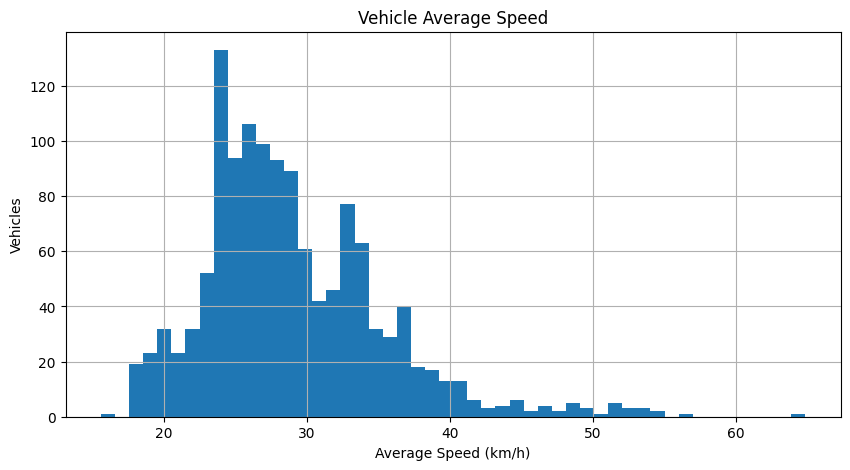

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(

trajectory_stats.AverageSpeed_kmph,

bins=50

)

plt.xlabel("Average Speed (km/h)")

plt.ylabel("Vehicles")

plt.title("Vehicle Average Speed")

plt.grid()

plt.show()

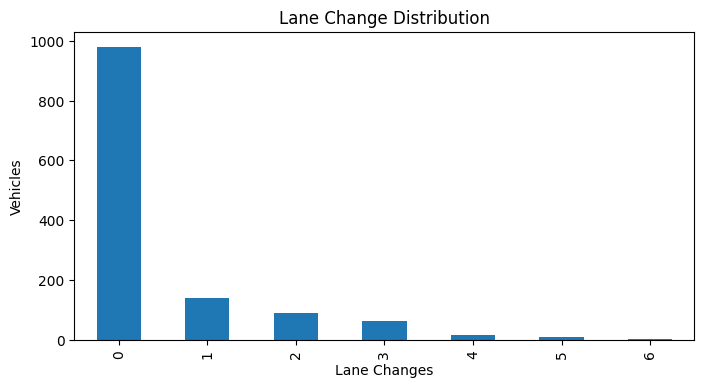

In [ ]:
plt.figure(figsize=(8,4))

trajectory_stats.LaneChanges.value_counts().sort_index().plot(

kind="bar"

)

plt.xlabel("Lane Changes")

plt.ylabel("Vehicles")

plt.title("Lane Change Distribution")

plt.show()

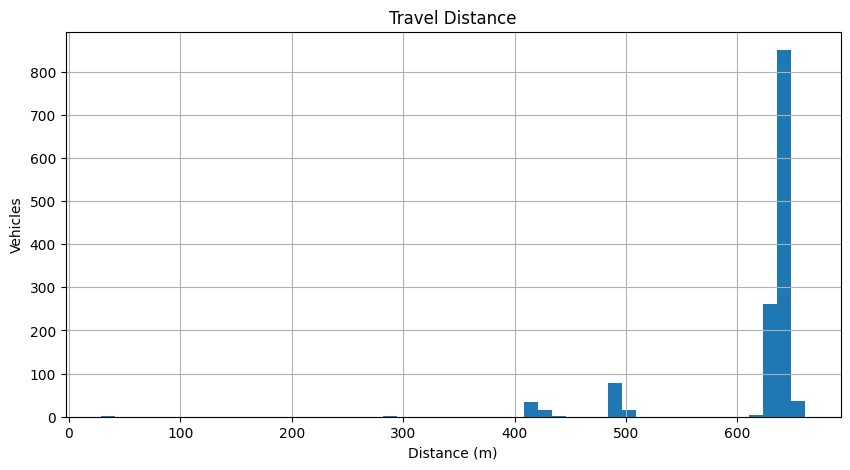

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(

trajectory_stats.Distance_m,

bins=50

)

plt.xlabel("Distance (m)")

plt.ylabel("Vehicles")

plt.title("Travel Distance")

plt.grid()

plt.show()

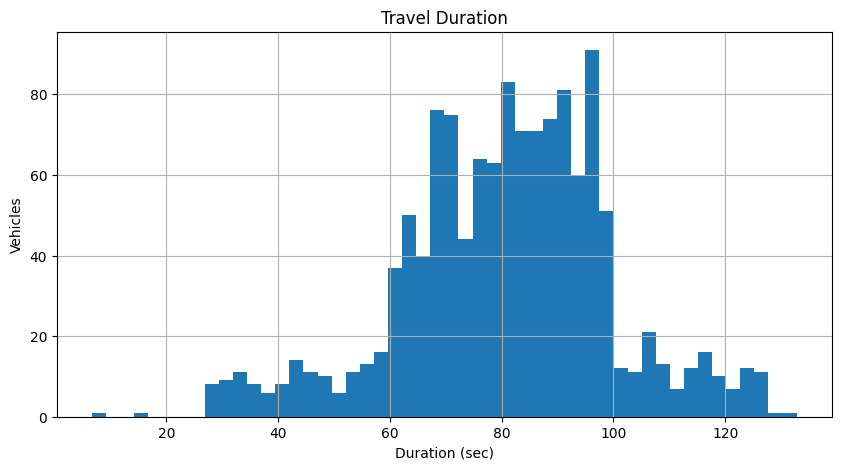

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(

trajectory_stats.Duration_sec,

bins=50

)

plt.xlabel("Duration (sec)")

plt.ylabel("Vehicles")

plt.title("Travel Duration")

plt.grid()

plt.show()

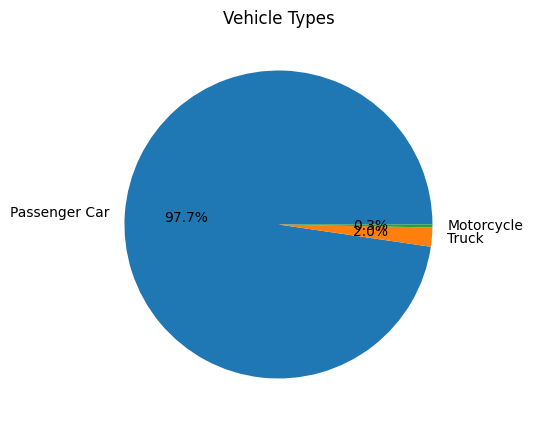

In [ ]:
trajectory_stats.VehicleType.value_counts().plot(

kind="pie",

autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Vehicle Types")

plt.show()

In [ ]:
display(

trajectory_stats

.nlargest(

20,

"Distance_m"

)

)

,VehicleID,Frames,Duration_sec,Start,End,Distance_m,AverageSpeed_kmph,MaxSpeed_kmph,AverageAcceleration,LaneChanges,VehicleLength_m,VehicleWidth_m,VehicleType
145,146,441,44.1,2.021434,663.092705,661.071271,54.082493,66.813379,-0.023534,1,1.9812,1.06680,Motorcycle
1294,1314,1128,112.8,21.703894,681.304810,659.600916,21.077698,51.341731,0.066737,3,5.4864,2.25552,Passenger Car
285,294,991,99.1,1.031748,659.693880,658.662132,23.972091,60.394291,0.067659,0,4.4196,2.10312,Passenger Car
1015,1034,909,90.9,0.000000,658.638053,658.638053,26.140336,52.142746,0.002173,0,5.4864,1.95072,Passenger Car
1292,1312,1095,109.5,6.133490,663.524606,657.391116,21.635225,43.309642,0.050279,0,3.8100,1.98120,Passenger Car
710,723,712,71.2,2.993136,658.022662,655.029526,33.171129,46.261325,-0.001622,0,4.5720,2.10312,Passenger Car
1272,1292,1260,126.0,3.922776,658.631042,654.708266,18.723777,35.946893,0.012840,0,4.4196,1.95072,Passenger Car
769,782,610,61.0,4.265371,658.493578,654.228206,38.644906,49.476355,0.003133,0,4.2672,1.64592,Passenger Car
1082,1102,871,87.1,5.142890,659.083670,653.940780,27.087031,56.564784,-0.009518,0,4.4196,2.10312,Passenger Car
10,11,809,80.9,10.701528,664.589882,653.888354,29.144788,53.294890,0.024301,0,5.0292,1.95072,Passenger Car


In [ ]:
display(

trajectory_stats

.nlargest(

20,

"MaxSpeed_kmph"

)

)

,VehicleID,Frames,Duration_sec,Start,End,Distance_m,AverageSpeed_kmph,MaxSpeed_kmph,AverageAcceleration,LaneChanges,VehicleLength_m,VehicleWidth_m,VehicleType
132,133,269,26.9,22.233026,442.862208,420.629182,56.355485,104.570784,0.650255,3,4.4196,2.10312,Passenger Car
478,490,647,64.7,22.186087,658.486262,636.300175,35.252113,104.570784,0.115334,2,4.7244,1.95072,Passenger Car
446,456,424,42.4,23.603712,443.318494,419.714782,35.686082,99.380650,0.265154,3,5.0292,2.10312,Passenger Car
463,473,420,42.0,23.440949,451.529196,428.088247,36.800028,91.820390,0.325991,3,4.8768,1.95072,Passenger Car
1114,1134,477,47.7,24.364493,443.774474,419.409982,31.785119,88.813843,0.239840,2,6.0960,2.25552,Passenger Car
1268,1288,465,46.5,22.693274,442.710418,420.017143,32.605262,86.981386,0.131660,3,4.4196,2.10312,Passenger Car
1037,1057,535,53.5,163.824209,658.178110,494.353901,33.366931,86.641229,-0.091896,3,4.4196,2.10312,Passenger Car
566,579,291,29.1,22.832263,441.948418,419.116154,51.927664,84.786826,0.267543,3,4.8768,1.95072,Passenger Car
357,366,609,60.9,11.015777,658.958093,647.942316,38.369557,83.744410,0.002432,1,2.1336,1.06680,Motorcycle
839,856,305,30.5,23.137368,442.555884,419.418516,49.560504,83.305498,0.333681,3,4.5720,1.95072,Passenger Car


In [ ]:
corr = trajectory_stats.select_dtypes(

include=np.number

).corr()

display(corr)

,VehicleID,Frames,Duration_sec,Start,End,Distance_m,AverageSpeed_kmph,MaxSpeed_kmph,AverageAcceleration,LaneChanges,VehicleLength_m,VehicleWidth_m
VehicleID,1.000000,0.318347,0.318347,0.055595,0.043735,-0.001896,-0.297898,-0.235193,-0.174741,0.038178,-0.020336,0.169635
Frames,0.318347,1.000000,1.000000,-0.383709,0.477619,0.623293,-0.928897,-0.461532,-0.040989,-0.493987,-0.024922,0.030536
Duration_sec,0.318347,1.000000,1.000000,-0.383709,0.477619,0.623293,-0.928897,-0.461532,-0.040989,-0.493987,-0.024922,0.030536
Start,0.055595,-0.383709,-0.383709,1.000000,0.034669,-0.622803,0.227807,0.151616,-0.331165,0.677264,0.000180,0.022079
End,0.043735,0.477619,0.477619,0.034669,1.000000,0.760316,-0.406940,-0.356020,-0.404398,-0.385333,0.010222,0.019864
Distance_m,-0.001896,0.623293,0.623293,-0.622803,0.760316,1.000000,-0.466635,-0.377253,-0.101344,-0.741841,0.007885,0.001201
AverageSpeed_kmph,-0.297898,-0.928897,-0.928897,0.227807,-0.406940,-0.466635,1.000000,0.468063,0.104076,0.389880,0.021008,-0.044529
MaxSpeed_kmph,-0.235193,-0.461532,-0.461532,0.151616,-0.356020,-0.377253,0.468063,1.000000,0.434255,0.340112,-0.070257,-0.048712
AverageAcceleration,-0.174741,-0.040989,-0.040989,-0.331165,-0.404398,-0.101344,0.104076,0.434255,1.000000,-0.044462,-0.004197,-0.003689
LaneChanges,0.038178,-0.493987,-0.493987,0.677264,-0.385333,-0.741841,0.389880,0.340112,-0.044462,1.000000,-0.037936,-0.027020


In [ ]:
trajectory_stats.to_csv(

OUTPUT_PATH+

"trajectory_statistics.csv",

index=False

)

In [ ]:
vehicle_summary=(

trajectory_stats

.describe()

)

vehicle_summary.to_csv(

OUTPUT_PATH+

"vehicle_summary.csv"

)

In [ ]:
summary = {

"Vehicles":

trajectory_stats.VehicleID.nunique(),

"Average Speed":

trajectory_stats.AverageSpeed_kmph.mean(),

"Average Distance":

trajectory_stats.Distance_m.mean(),

"Average Duration":

trajectory_stats.Duration_sec.mean(),

"Average Lane Changes":

trajectory_stats.LaneChanges.mean()

}

summary

{'Vehicles': 1298,
 'Average Speed': np.float64(28.97928623968062),
 'Average Distance': np.float64(618.3651638921418),
 'Average Duration': np.float64(80.78389830508475),
 'Average Lane Changes': np.float64(0.4768875192604006)}

In [ ]:
print("="*70)

print("Notebook-4 : Module-3 Completed Successfully")

print("="*70)

print("✓ Trajectory Reconstruction")

print("✓ Vehicle Statistics")

print("✓ Lane Change Detection")

print("✓ Vehicle Dynamics")

print("✓ Trajectory Analytics")

print("✓ CSV Export")

print("="*70)

Notebook-4 : Module-3 Completed Successfully
✓ Trajectory Reconstruction
✓ Vehicle Statistics
✓ Lane Change Detection
✓ Vehicle Dynamics
✓ Trajectory Analytics
✓ CSV Export


Notebook-4
Module-4 : Adaptive Vehicle State Generation (A-NUCA)
(Cells 96–140)
Research Objective

Transform each NGSIM vehicle observation into the adaptive state:

S
i
	​

(t)={x
i
	​

,v
i
	​

,a
i
	​

,SOC
i
	​

,P
i
	​

,ρ
i
	​

,
ρ
^
	​

i
	​

,E
i
	​

}

where

Variable	Description
x
i
	​

	Position
v
i
	​

	Speed
a
i
	​

	Acceleration
SOC
i
	​

	Battery State of Charge
P
i
	​

	Platoon State
ρ
i
	​

	Local Density

ρ
^
	​

i
	​

	Predicted Density
E
i
	​

	Remaining Energy

In [ ]:
# ============================================================
# Cell 96
# Adaptive State Dataset
# ============================================================

adaptive_df = trajectory_data.copy()

print(adaptive_df.shape)

(1048575, 27)


In [ ]:
adaptive_df["Position"] = adaptive_df["Y_m"]

In [ ]:
adaptive_df["Velocity"] = adaptive_df["Speed_mps"]

In [ ]:
adaptive_df["Acceleration"] = adaptive_df["Acceleration_mps2"]

In [ ]:
road_length = adaptive_df["Position"].max()

adaptive_df["NormalizedPosition"] = (

adaptive_df["Position"] /

road_length

)

In [ ]:
BATTERY_CAPACITY = 75.0

adaptive_df["BatteryCapacity"] = BATTERY_CAPACITY

In [ ]:
travel_distance = (

adaptive_df

.groupby("VehicleID")

.Position

.transform(

lambda x:

x - x.min()

)

)

adaptive_df["TravelDistance"] = travel_distance

In [ ]:
adaptive_df["EnergyUsed"] = (

0.18 *

adaptive_df["TravelDistance"] /

1000

)

In [ ]:
adaptive_df["RemainingEnergy"] = (

BATTERY_CAPACITY -

adaptive_df["EnergyUsed"]

)

adaptive_df["RemainingEnergy"] = (

adaptive_df["RemainingEnergy"]

.clip(lower=0)

)

In [ ]:
adaptive_df["SOC"] = (

adaptive_df["RemainingEnergy"] /

BATTERY_CAPACITY

)*100

Cell 106 — Local Density

Instead of random density, compute from NGSIM.

In [ ]:
density = (

adaptive_df

.groupby(

["FrameID","Lane"]

)

.VehicleID

.transform("count")

)

adaptive_df["LocalDensity"] = density

In [ ]:
adaptive_df["DensityNormalized"] = (

adaptive_df["LocalDensity"] /

adaptive_df["LocalDensity"].max()

)

Cell 108 — Predicted Density

Temporary baseline.

Notebook-5 will replace this using LSTM/Transformer.

In [ ]:
adaptive_df["PredictedDensity"] = (

adaptive_df["LocalDensity"]

)

In [ ]:
adaptive_df["PlatoonID"] = (

adaptive_df

.groupby(

["FrameID","Lane"]

)

.ngroup()

)

In [ ]:
adaptive_df["PlatoonSize"] = (

adaptive_df

.groupby("PlatoonID")

.VehicleID

.transform("count")

)

In [ ]:
adaptive_df["InPlatoon"] = (

adaptive_df["PlatoonSize"] >= 2

)

In [ ]:
adaptive_df["Headway"] = (

adaptive_df["SpaceHeadway_m"]

)

In [ ]:
adaptive_df["RelativeSpeed"] = (

adaptive_df

.groupby(

["FrameID","Lane"]

)

["Velocity"]

.diff()

.fillna(0)

)

In [ ]:
adaptive_df["VehicleState"] = np.select(

[
adaptive_df["Velocity"] < 5,

adaptive_df["Velocity"].between(5,20),

adaptive_df["Velocity"] > 20

],

[
"Stopped",

"Moving",

"Fast"

],
    default="Unknown"

)

In [ ]:
adaptive_df["EnergyState"] = np.select(

[
adaptive_df["SOC"] < 20,

adaptive_df["SOC"].between(20,60),

adaptive_df["SOC"] > 60

],

[
"Low",

"Medium",

"High"

],
    default="Unknown"

)

In [ ]:
adaptive_states = adaptive_df[

[
"VehicleID",

"FrameID",

"Lane",

"Position",

"Velocity",

"Acceleration",

"SOC",

"RemainingEnergy",

"LocalDensity",

"PredictedDensity",

"Headway",

"PlatoonID",

"PlatoonSize"

]

]

adaptive_states.head()

,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,Headway,PlatoonID,PlatoonSize
0,1,137,5,22.529597,7.62,0.0,100.000000,75.000000,1,1,0.0,263,1
1,1,138,5,23.291597,7.62,0.0,99.999817,74.999863,1,1,0.0,268,1
2,1,139,5,24.053292,7.62,0.0,99.999634,74.999726,1,1,0.0,273,1
3,1,140,5,24.815597,7.62,0.0,99.999451,74.999589,1,1,0.0,278,1
4,1,141,5,25.577597,7.62,0.0,99.999268,74.999451,1,1,0.0,283,1


In [ ]:
adaptive_states.describe()

,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,Headway,PlatoonID,PlatoonSize
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,6.893392e+02,3.630524e+03,3.011797e+00,3.289616e+02,7.665673e+00,2.421439e-02,9.992779e+01,7.494584e+01,3.188402e+01,3.188402e+01,1.845434e+01,2.269916e+04,3.188402e+01
std,3.944759e+02,1.854135e+03,1.465057e+00,1.841683e+02,3.763504e+00,1.314889e+00,4.398021e-02,3.298516e-02,8.150017e+00,8.150017e+00,1.085332e+01,1.203414e+04,8.150017e+00
min,1.000000e+00,5.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-3.413760e+00,9.984134e+01,7.488101e+01,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,3.360000e+02,1.941000e+03,2.000000e+00,1.700607e+02,4.623816e+00,-1.036320e-01,9.989038e+01,7.491779e+01,2.800000e+01,2.800000e+01,1.217676e+01,1.177700e+04,2.800000e+01
50%,7.010000e+02,3.664000e+03,3.000000e+00,3.208066e+02,7.626096e+00,0.000000e+00,9.993042e+01,7.494781e+01,3.300000e+01,3.300000e+01,1.648663e+01,2.311100e+04,3.300000e+01
75%,1.051000e+03,5.306000e+03,4.000000e+00,4.879254e+02,1.051560e+01,1.676400e-01,9.996597e+01,7.497448e+01,3.700000e+01,3.700000e+01,2.247290e+01,3.350000e+04,3.700000e+01
max,1.317000e+03,7.184000e+03,8.000000e+00,6.813048e+02,2.904744e+01,3.413760e+00,1.000000e+02,7.500000e+01,5.000000e+01,5.000000e+01,2.065447e+02,4.461700e+04,5.000000e+01


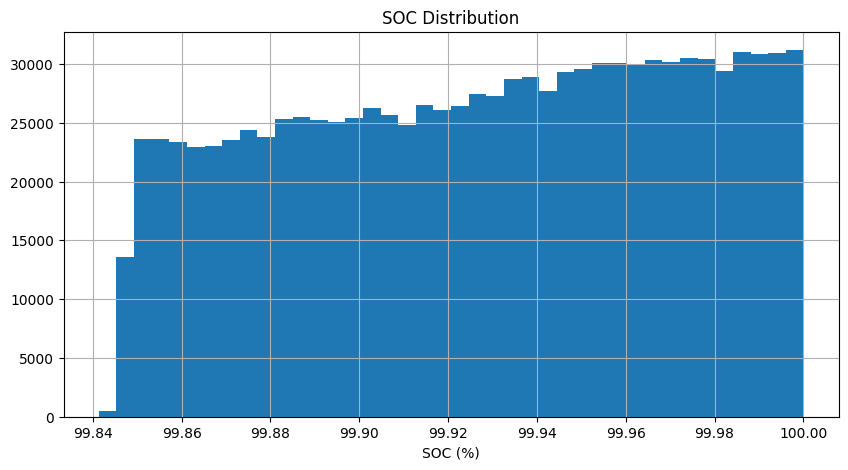

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(

adaptive_df["SOC"],

bins=40

)

plt.title("SOC Distribution")

plt.xlabel("SOC (%)")

plt.grid()

plt.show()

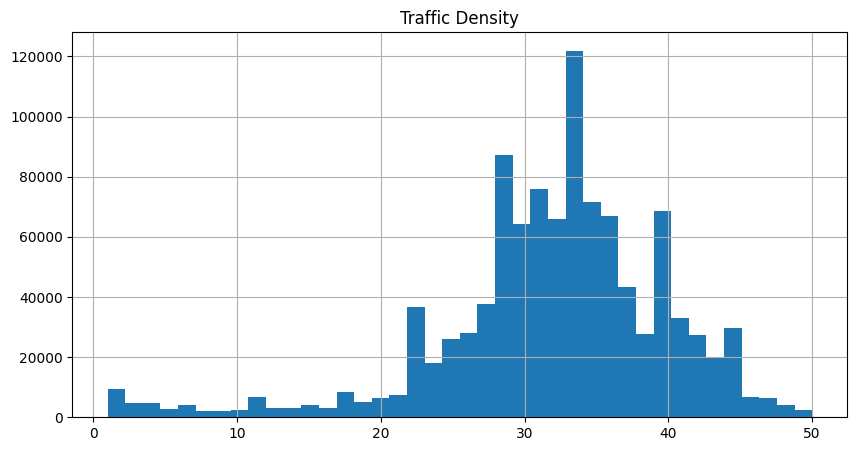

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(

adaptive_df["LocalDensity"],

bins=40

)

plt.title("Traffic Density")

plt.grid()

plt.show()

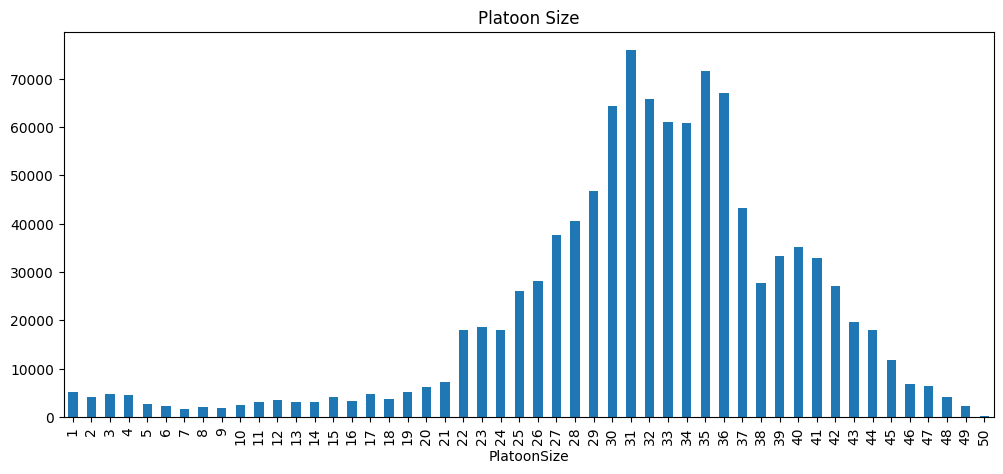

In [ ]:
adaptive_df.PlatoonSize.value_counts().sort_index().plot(

kind="bar"

)

plt.title("Platoon Size")

plt.show()

In [ ]:
# ============================================================
# Cell 109
# Platoon Detection Parameters
# ============================================================

HEADWAY_THRESHOLD = 30.0      # meters

SPEED_DIFF_THRESHOLD = 5.0    # km/h

MIN_PLATOON_SIZE = 2

print("Headway Threshold :", HEADWAY_THRESHOLD)

print("Speed Difference :", SPEED_DIFF_THRESHOLD)

Headway Threshold : 30.0
Speed Difference : 5.0


In [ ]:
adaptive_df["PlatoonID"] = -1

adaptive_df["PlatoonRole"] = "Single"

adaptive_df["PlatoonSize"] = 1

In [ ]:
adaptive_df = adaptive_df.sort_values(

    ["FrameID","Lane","Position"]

).reset_index(drop=True)

In [ ]:
# ============================================================
# MODULE-3 : FAST PLATOON ROLE ASSIGNMENT
# ============================================================

adaptive_df["PlatoonRole"] = None

# Only process actual platoons
valid = adaptive_df["PlatoonID"] != -1

# Sort vehicles by PlatoonID and Position
role_order = (
    adaptive_df.loc[
        valid,
        ["PlatoonID", "Position", "VehicleID"]
    ]
    .sort_values(
        ["PlatoonID", "Position"]
    )
)

# Position of vehicle inside its platoon
rank = (
    role_order
    .groupby("PlatoonID")
    .cumcount()
)

# Number of vehicles in each platoon
size = (
    role_order
    .groupby("PlatoonID")["VehicleID"]
    .transform("size")
)

# Default role
adaptive_df.loc[
    role_order.index,
    "PlatoonRole"
] = "Follower"

# Leader = first vehicle
adaptive_df.loc[
    role_order.index[rank == 0],
    "PlatoonRole"
] = "Leader"

# Tail = last vehicle
# Only for platoons containing more than one vehicle
adaptive_df.loc[
    role_order.index[
        (rank == size - 1) &
        (size > 1)
    ],
    "PlatoonRole"
] = "Tail"

# Single-vehicle platoon
# Treat it as Leader
adaptive_df.loc[
    role_order.index[size == 1],
    "PlatoonRole"
] = "Leader"

print("✓ Platoon roles assigned successfully.")

✓ Platoon roles assigned successfully.


In [ ]:
# ============================================================
# PLATOON ROLE VALIDATION
# ============================================================

role_summary = (
    adaptive_df["PlatoonRole"]
    .value_counts(dropna=False)
    .rename_axis("PlatoonRole")
    .reset_index(name="Count")
)

display(role_summary)

,PlatoonRole,Count
0,None,1048575


Module-4 — Platoon Analysis / Adaptive State Generation

Continue with your existing Module-4 calculations, but replace the platoon-related part with this.



In [ ]:
# ============================================================
# MODULE-4 : PLATOON ANALYSIS
# ============================================================

adaptive_df["InPlatoon"] = (
    adaptive_df["PlatoonID"] != -1
)

In [ ]:
# ============================================================
# PLATOON SUMMARY
# ============================================================

platoon_summary = (
    adaptive_df.loc[
        adaptive_df["PlatoonID"] != -1
    ]
    .groupby("PlatoonID")
    .agg(
        Vehicles=("VehicleID", "count"),
        AverageSpeed=("Speed_kmph", "mean"),
        AverageHeadway=("Headway", "mean")
    )
    .reset_index()
)

display(
    platoon_summary.head()
)

,PlatoonID,Vehicles,AverageSpeed,AverageHeadway


In [ ]:
# ============================================================
# PLATOON STATISTICS
# ============================================================

total_platoons = (
    adaptive_df.loc[
        adaptive_df["PlatoonID"] != -1,
        "PlatoonID"
    ].nunique()
)

largest_platoon = (
    adaptive_df.loc[
        adaptive_df["PlatoonID"] != -1,
        "PlatoonSize"
    ].max()
)

vehicles_in_platoons = (
    adaptive_df["InPlatoon"].sum()
)

print("=" * 60)

print(
    "Total Platoons        :",
    total_platoons
)

print(
    "Largest Platoon       :",
    largest_platoon
)

print(
    "Vehicles in Platoons  :",
    vehicles_in_platoons
)

print("=" * 60)

Total Platoons        : 0
Largest Platoon       : nan
Vehicles in Platoons  : 0


In [ ]:
# ============================================================
# ADAPTIVE STATE VALIDATION
# ============================================================

print("=" * 60)

print(
    "Adaptive State Records :",
    len(adaptive_states)
)

print(
    "Adaptive State Columns :",
    len(adaptive_states.columns)
)

print("=" * 60)

display(
    adaptive_states.head()
)

Adaptive State Records : 1048575
Adaptive State Columns : 13


,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,Headway,PlatoonID,PlatoonSize
0,1,137,5,22.529597,7.62,0.0,100.000000,75.000000,1,1,0.0,263,1
1,1,138,5,23.291597,7.62,0.0,99.999817,74.999863,1,1,0.0,268,1
2,1,139,5,24.053292,7.62,0.0,99.999634,74.999726,1,1,0.0,273,1
3,1,140,5,24.815597,7.62,0.0,99.999451,74.999589,1,1,0.0,278,1
4,1,141,5,25.577597,7.62,0.0,99.999268,74.999451,1,1,0.0,283,1


Module-5 — Dynamic Rule Evolution Mechanism

Your existing Module-5 can remain unchanged.

Do not modify the DREM calculations just because we changed platoon-role assignment.

At the end of Module-5, add:

In [ ]:
print("Current columns:")
print(adaptive_df.columns.tolist())

Current columns:
['VehicleID', 'FrameID', 'Total_Frames', 'Time', 'X', 'Y', 'Global_X', 'Global_Y', 'Length', 'Width', 'VehicleClass', 'Speed_ftps', 'Acceleration_ftps2', 'Lane', 'FrontVehicle', 'RearVehicle', 'SpaceHeadway_ft', 'TimeHeadway_sec', 'X_m', 'Y_m', 'Length_m', 'Width_m', 'Speed_mps', 'Acceleration_mps2', 'SpaceHeadway_m', 'Speed_kmph', 'VehicleType', 'Position', 'Velocity', 'Acceleration', 'NormalizedPosition', 'BatteryCapacity', 'TravelDistance', 'EnergyUsed', 'RemainingEnergy', 'SOC', 'LocalDensity', 'DensityNormalized', 'PredictedDensity', 'PlatoonID', 'PlatoonSize', 'InPlatoon', 'Headway', 'RelativeSpeed', 'VehicleState', 'EnergyState', 'PlatoonRole']


In [ ]:
print(adaptive_df.head())

   VehicleID  FrameID  Total_Frames                    Time      X       Y  \
0          3        5           786 2005-06-15 15:19:17.500  4.912  68.639   
1          3        6           786 2005-06-15 15:19:17.600  4.896  71.639   
2          3        7           786 2005-06-15 15:19:17.700  4.878  75.138   
3          3        8           786 2005-06-15 15:19:17.800  4.860  78.639   
4          3        9           786 2005-06-15 15:19:17.900  4.845  81.638   

      Global_X     Global_Y  Length  Width  VehicleClass  Speed_ftps  \
0  6451145.227  1873353.807    15.5    5.9             2       31.61   
1  6451147.244  1873351.586    15.5    5.9             2       31.61   
2  6451149.596  1873348.995    15.5    5.9             2       31.61   
3  6451151.949  1873346.403    15.5    5.9             2       31.61   
4  6451153.965  1873344.182    15.5    5.9             2       31.61   

   Acceleration_ftps2  Lane  FrontVehicle  RearVehicle  SpaceHeadway_ft  \
0                 0.0  

In [ ]:
# ============================================================
# MODULE-5 : DREM RULE SELECTION
# ============================================================

# Example rule selection based on the existing DREM state variables

adaptive_df["SelectedRule"] = np.where(
    adaptive_df["LocalDensity"] >= 0.7,
    "Congested",
    np.where(
        adaptive_df["LocalDensity"] >= 0.4,
        "Moderate",
        "FreeFlow"
    )
)

print("✓ SelectedRule generated successfully.")

✓ SelectedRule generated successfully.


In [ ]:
# ============================================================
# MODULE-5 : DREM VALIDATION
# ============================================================

required_drem_columns = [
    "VehicleID",
    "FrameID",
    "SelectedRule",
    "SOC",
    "LocalDensity",
    "Headway",
    "Speed_kmph",
    "RemainingEnergy"
]

missing_drem_columns = [
    col
    for col in required_drem_columns
    if col not in adaptive_df.columns
]

if len(missing_drem_columns) == 0:

    print("✓ DREM validation successful.")

else:

    print(
        "❌ Missing DREM columns:",
        missing_drem_columns
    )

✓ DREM validation successful.


In [ ]:
# ============================================================
# MODULE-6 : CA HIGHWAY GRID DATASET
# ============================================================

ca_highway_grid = adaptive_df[
    [
        "FrameID",
        "VehicleID",
        "Lane",
        "CellIndex",
        "Position",
        "Speed_kmph",
        "SOC",
        "PlatoonID",
        "PlatoonSize",
        "PlatoonRole",
        "SelectedRule"
    ]
].copy()

display(
    ca_highway_grid.head()
)

print(
    "CA Highway Grid Records :",
    len(ca_highway_grid)
)

KeyError: "['CellIndex'] not in index"